In [ ]:
!pip install pandas numpy plotly geopandas country_converter -q


In [2]:
# Step 1: Install Kaggle
!pip install kaggle -q

# Step 2: Upload your kaggle.json
from google.colab import files
files.upload()  # Click upload → select kaggle.json from your computer

# Step 3: Set up credentials
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Step 4: Download + unzip
!kaggle datasets download -d shashwatwork/dataco-smart-supply-chain-for-big-data-analysis -p /content/
!unzip -q /content/dataco-smart-supply-chain-for-big-data-analysis.zip -d /content/dataco/
!ls /content/dataco/

Saving DataCoSupplyChainDataset.csv to DataCoSupplyChainDataset.csv
cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Dataset URL: https://www.kaggle.com/datasets/shashwatwork/dataco-smart-supply-chain-for-big-data-analysis
License(s): CC0-1.0
100% 25.7M/25.7M [00:01<00:00, 19.8MB/s]

DataCoSupplyChainDataset.csv	  tokenized_access_logs.csv
DescriptionDataCoSupplyChain.csv


In [3]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")

# Load directly from where Colab saved it
df = pd.read_csv("DataCoSupplyChainDataset.csv", encoding="ISO-8859-1")

print(f"✅ Rows:    {df.shape[0]:,}")
print(f"✅ Columns: {df.shape[1]}")
print(f"✅ Memory:  {df.memory_usage().sum() / 1e6:.1f} MB")

✅ Rows:    180,519
✅ Columns: 53
✅ Memory:  76.5 MB


In [4]:
cols = [
    "Order Country", "Order Region", "Order City",
    "Latitude", "Longitude",
    "Shipping Mode", "Days for shipping (real)",
    "Days for shipment (scheduled)", "Late_delivery_risk",
    "Delivery Status", "Order Status",
    "Sales", "Order Item Quantity",
    "Order Item Profit Ratio", "Category Name"
]

df = df[cols].copy()

df.columns = [
    "country", "region", "city",
    "lat", "lon",
    "ship_mode", "days_actual",
    "days_scheduled", "late_risk",
    "delivery_status", "order_status",
    "sales", "quantity",
    "profit_ratio", "category"
]

print(f"✅ Trimmed shape: {df.shape}")
print(df.dtypes)

✅ Trimmed shape: (180519, 15)
country             object
region              object
city                object
lat                float64
lon                float64
ship_mode           object
days_actual          int64
days_scheduled       int64
late_risk            int64
delivery_status     object
order_status        object
sales              float64
quantity             int64
profit_ratio       float64
category            object
dtype: object


In [5]:
print("=== Missing Values ===")
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print(missing if len(missing) > 0 else "✅ No missing values")

print(f"\n=== Duplicates ===")
dupes = df.duplicated().sum()
print(f"Duplicate rows: {dupes}")
df = df.drop_duplicates()
print(f"✅ Clean shape after dedup: {df.shape}")

=== Missing Values ===
✅ No missing values

=== Duplicates ===
Duplicate rows: 336
✅ Clean shape after dedup: (180183, 15)


In [6]:
df["lat"]           = pd.to_numeric(df["lat"], errors="coerce")
df["lon"]           = pd.to_numeric(df["lon"], errors="coerce")
df["sales"]         = pd.to_numeric(df["sales"], errors="coerce")
df["days_actual"]   = pd.to_numeric(df["days_actual"], errors="coerce")
df["days_scheduled"]= pd.to_numeric(df["days_scheduled"], errors="coerce")

# Core feature for risk scoring
df["lead_time_variance"] = df["days_actual"] - df["days_scheduled"]

print("✅ Types fixed")
print(df.head(3))

✅ Types fixed
     country          region     city        lat         lon       ship_mode  \
0  Indonesia  Southeast Asia   Bekasi  18.251453  -66.037056  Standard Class   
1      India      South Asia  Bikaner  18.279451  -66.037064  Standard Class   
2      India      South Asia  Bikaner  37.292233 -121.881279  Standard Class   

   days_actual  days_scheduled  late_risk   delivery_status order_status  \
0            3               4          0  Advance shipping     COMPLETE   
1            5               4          1     Late delivery      PENDING   
2            4               4          0  Shipping on time       CLOSED   

    sales  quantity  profit_ratio        category  lead_time_variance  
0  327.75         1          0.29  Sporting Goods                  -1  
1  327.75         1         -0.80  Sporting Goods                   1  
2  327.75         1         -0.80  Sporting Goods                   0  


In [7]:
country_risk = df.groupby("country").agg(
    total_orders    = ("late_risk", "count"),
    late_orders     = ("late_risk", "sum"),
    avg_sales       = ("sales", "mean"),
    avg_lead_var    = ("lead_time_variance", "mean")
).reset_index()

country_risk["late_rate_%"] = (
    country_risk["late_orders"] / country_risk["total_orders"] * 100
).round(2)

country_risk = country_risk.sort_values("late_rate_%", ascending=False)
print("=== Top 15 Riskiest Countries ===")
print(country_risk.head(15).to_string(index=False))

=== Top 15 Riskiest Countries ===
            country  total_orders  late_orders  avg_sales  avg_lead_var  late_rate_%
              Bután             5            5 153.920003      2.000000       100.00
            Armenia             5            5  91.180000      1.000000       100.00
  Guinea Ecuatorial             2            2 159.980003      1.500000       100.00
            Eritrea             2            2 154.980003      2.000000       100.00
República de Gambia             5            5 289.972003      2.000000       100.00
  Sáhara Occidental             2            2 299.980003      2.000000       100.00
      Sudán del Sur             5            5 175.988004      2.200000       100.00
        Suazilandia             5            5 251.982007      2.000000       100.00
               Laos             6            6 113.835004      1.833333       100.00
         Luxemburgo            10           10 176.472002      2.700000       100.00
            Estonia            

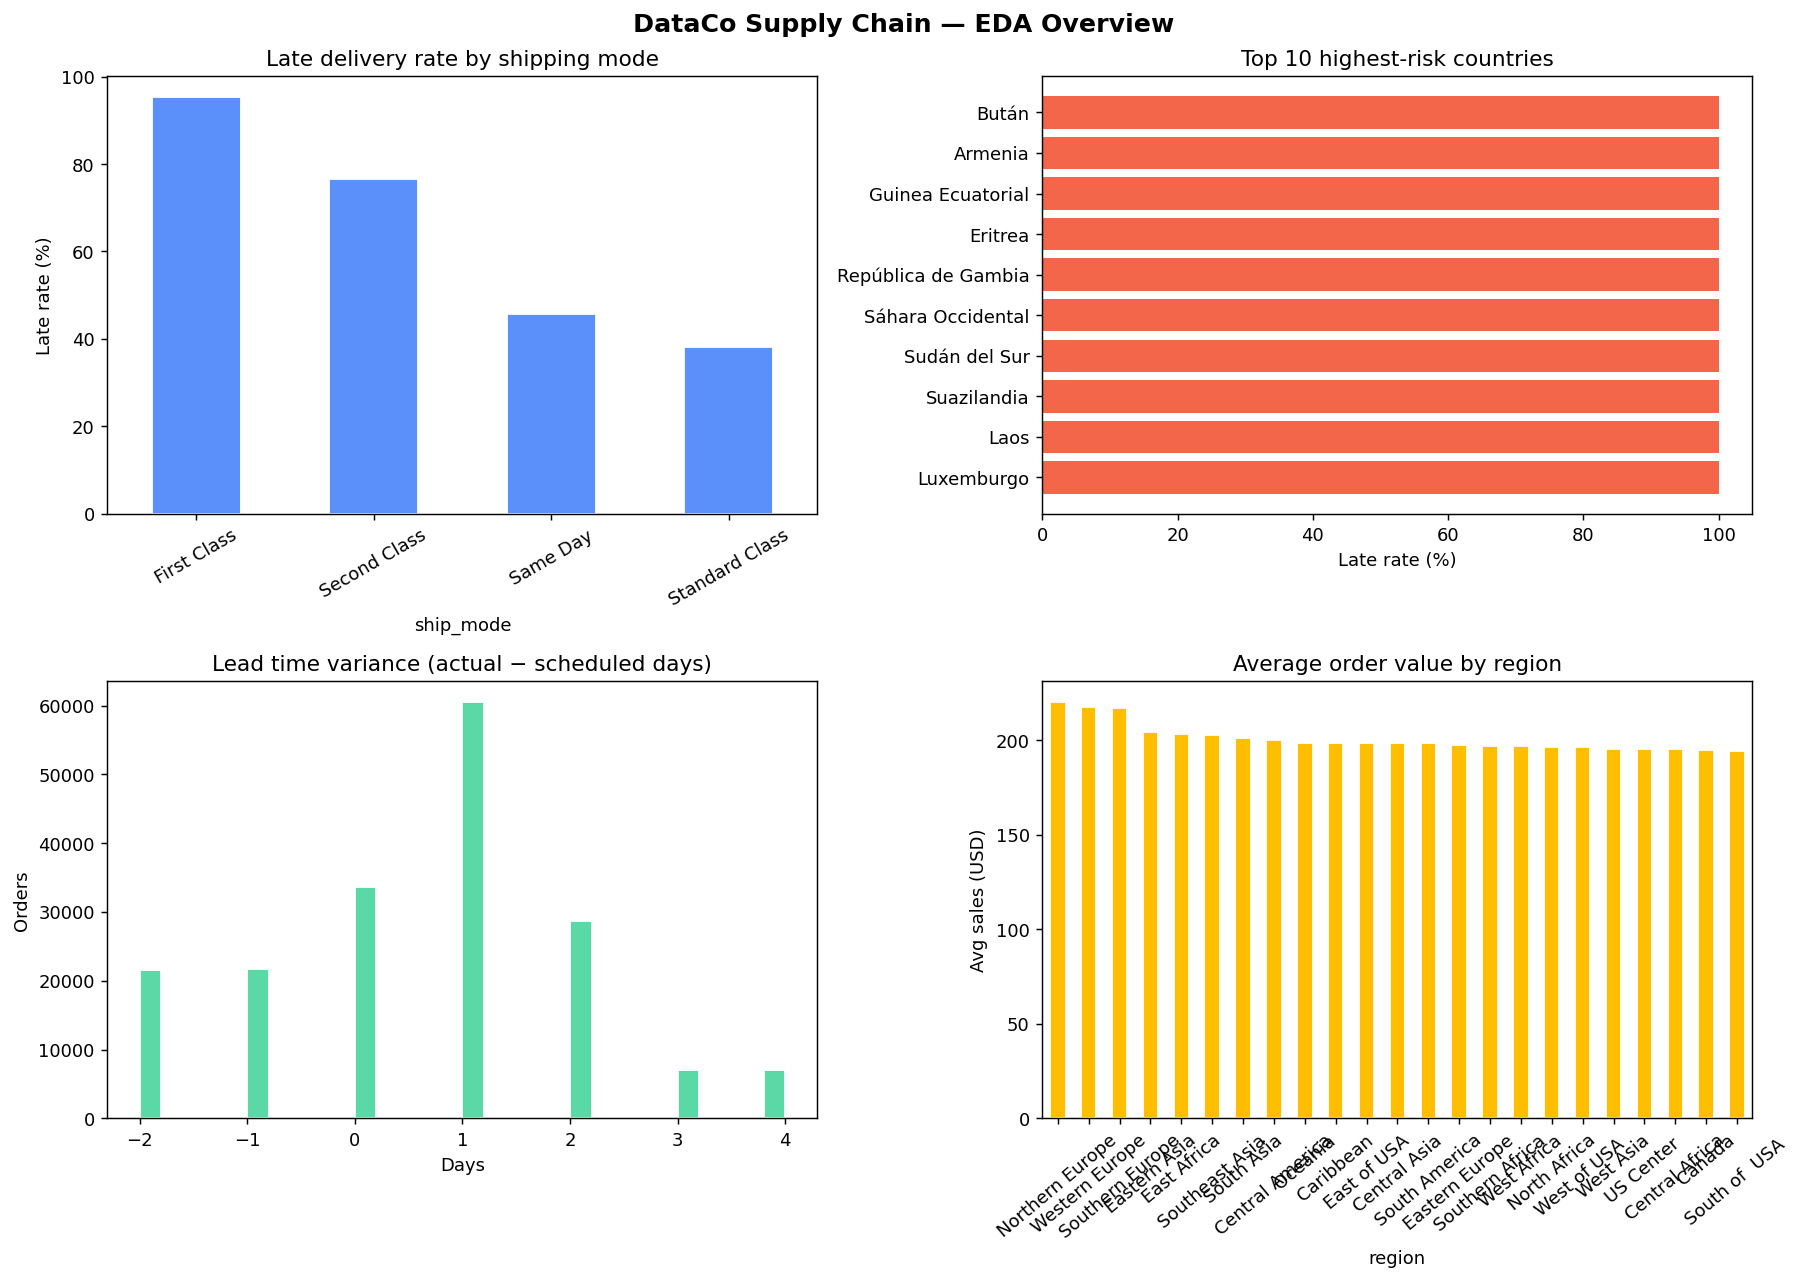

✅ Chart saved as eda_overview.png


In [8]:
import matplotlib
import matplotlib.pyplot as plt
matplotlib.rcParams["figure.dpi"] = 130

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("DataCo Supply Chain — EDA Overview", fontsize=14, fontweight="bold")

# Chart 1: Late rate by shipping mode
mode = df.groupby("ship_mode")["late_risk"].mean().sort_values(ascending=False) * 100
mode.plot(kind="bar", ax=axes[0,0], color="#5B8FF9", edgecolor="white")
axes[0,0].set_title("Late delivery rate by shipping mode")
axes[0,0].set_ylabel("Late rate (%)")
axes[0,0].tick_params(axis="x", rotation=30)

# Chart 2: Top 10 riskiest countries
top10 = country_risk.head(10)
axes[0,1].barh(top10["country"], top10["late_rate_%"], color="#F4664A")
axes[0,1].set_title("Top 10 highest-risk countries")
axes[0,1].set_xlabel("Late rate (%)")
axes[0,1].invert_yaxis()

# Chart 3: Lead time variance distribution
axes[1,0].hist(df["lead_time_variance"].dropna(), bins=30,
               color="#5AD8A6", edgecolor="white")
axes[1,0].set_title("Lead time variance (actual − scheduled days)")
axes[1,0].set_xlabel("Days")
axes[1,0].set_ylabel("Orders")

# Chart 4: Avg sales by region
region_sales = df.groupby("region")["sales"].mean().sort_values(ascending=False)
region_sales.plot(kind="bar", ax=axes[1,1], color="#FFBE00", edgecolor="white")
axes[1,1].set_title("Average order value by region")
axes[1,1].set_ylabel("Avg sales (USD)")
axes[1,1].tick_params(axis="x", rotation=40)

plt.tight_layout()
plt.savefig("eda_overview.png", bbox_inches="tight")
plt.show()
print("✅ Chart saved as eda_overview.png")

In [9]:
df.to_csv("dataco_clean.csv", index=False)
print(f"✅ Saved: dataco_clean.csv — {df.shape[0]:,} rows, {df.shape[1]} columns")


✅ Saved: dataco_clean.csv — 180,183 rows, 16 columns


In [10]:
# Filter countries with at least 30 orders (removes the 100% anomalies)
country_risk = df.groupby("country").agg(
    total_orders     = ("late_risk", "count"),
    late_orders      = ("late_risk", "sum"),
    avg_lead_var     = ("lead_time_variance", "mean"),
    avg_sales        = ("sales", "mean"),
    avg_profit_ratio = ("profit_ratio", "mean")
).reset_index()

country_risk = country_risk[country_risk["total_orders"] >= 30].copy()

country_risk["late_rate"]       = country_risk["late_orders"] / country_risk["total_orders"]
country_risk["lead_var_norm"]   = country_risk["avg_lead_var"].clip(lower=0)  # only positive variance matters

print(f"✅ Countries with 30+ orders: {len(country_risk)}")
print(country_risk.sort_values("late_rate", ascending=False).head(10).to_string(index=False))

✅ Countries with 30+ orders: 123
             country  total_orders  late_orders  avg_lead_var  avg_sales  avg_profit_ratio  late_rate  lead_var_norm
               Gabón            45           35      1.111111 205.644004          0.020889   0.777778       1.111111
               Túnez            36           28      0.861111 173.846392          0.160833   0.777778       0.861111
        Turkmenistán            53           37      0.679245 228.459250          0.023208   0.698113       0.679245
          Costa Rica            36           25      1.305556 165.199169          0.033889   0.694444       1.305556
            Moldavia            78           54      1.410256 196.808978          0.066410   0.692308       1.410256
Bosnia y Herzegovina            45           31      0.688889 197.090892         -0.039556   0.688889       0.688889
             Georgia            92           63      0.619565 196.718156          0.051739   0.684783       0.619565
              Yibuti           

In [11]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

# Signals to include in composite score
risk_signals = ["late_rate", "lead_var_norm"]

country_risk[[s + "_scaled" for s in risk_signals]] = scaler.fit_transform(
    country_risk[risk_signals]
)

# Weighted composite score
# late_rate = 60% weight (most direct signal)
# lead_var  = 40% weight (early warning signal)
country_risk["risk_score"] = (
    country_risk["late_rate_scaled"]   * 0.60 +
    country_risk["lead_var_norm_scaled"] * 0.40
).round(4)

# Risk tier labels
def assign_tier(score):
    if score >= 0.70: return "Critical"
    elif score >= 0.45: return "High"
    elif score >= 0.20: return "Medium"
    else: return "Low"

country_risk["risk_tier"] = country_risk["risk_score"].apply(assign_tier)

print("=== Risk Score by Country ===")
print(country_risk[["country", "total_orders", "late_rate",
                     "risk_score", "risk_tier"]]
      .sort_values("risk_score", ascending=False)
      .to_string(index=False))

=== Risk Score by Country ===
                        country  total_orders  late_rate  risk_score risk_tier
                          Gabón            45   0.777778      0.9116  Critical
                       Moldavia            78   0.692308      0.8769  Critical
                     Costa Rica            36   0.694444      0.8490  Critical
                          Túnez            36   0.777778      0.8377  Critical
                       Mongolia            79   0.658228      0.7889  Critical
                   Turkmenistán            53   0.698113      0.6692      High
           Bosnia y Herzegovina            45   0.688889      0.6588      High
                     Mozambique           244   0.639344      0.6394      High
                          Níger           106   0.650943      0.6375      High
                        Georgia            92   0.684783      0.6323      High
                         Yibuti            31   0.677419      0.6198      High
                      

=== Risk Tier Distribution ===
risk_tier
Medium      60
High        46
Low         12
Critical     5
Name: count, dtype: int64


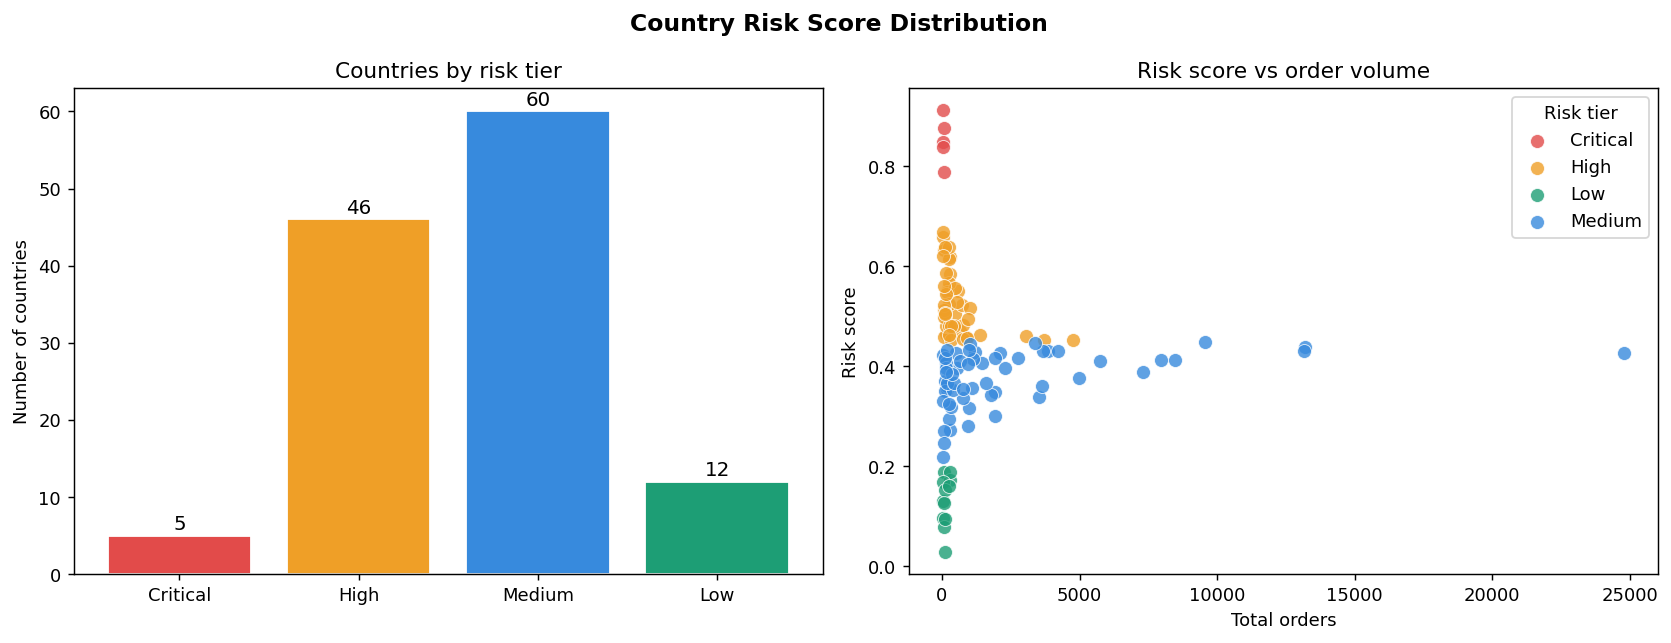

✅ Saved risk_scores.png


In [12]:
print("=== Risk Tier Distribution ===")
print(country_risk["risk_tier"].value_counts())

import matplotlib
import matplotlib.pyplot as plt

tier_colors = {"Critical": "#E24B4A", "High": "#EF9F27",
               "Medium": "#378ADD", "Low": "#1D9E75"}

tier_counts = country_risk["risk_tier"].value_counts().reindex(
    ["Critical", "High", "Medium", "Low"]
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Country Risk Score Distribution", fontsize=13, fontweight="bold")

# Bar chart — tier counts
bars = axes[0].bar(tier_counts.index, tier_counts.values,
                   color=[tier_colors[t] for t in tier_counts.index],
                   edgecolor="white")
axes[0].set_title("Countries by risk tier")
axes[0].set_ylabel("Number of countries")
for bar, val in zip(bars, tier_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.3, str(val),
                 ha="center", va="bottom", fontsize=11)

# Scatter — orders vs risk score
for tier, grp in country_risk.groupby("risk_tier"):
    axes[1].scatter(grp["total_orders"], grp["risk_score"],
                    label=tier, color=tier_colors[tier],
                    alpha=0.8, s=60, edgecolors="white", linewidths=0.5)

axes[1].set_title("Risk score vs order volume")
axes[1].set_xlabel("Total orders")
axes[1].set_ylabel("Risk score")
axes[1].legend(title="Risk tier")

plt.tight_layout()
plt.savefig("risk_scores.png", bbox_inches="tight")
plt.show()
print("✅ Saved risk_scores.png")

In [13]:
# Get average lat/lon per country from the original df
geo = df.groupby("country").agg(
    lat = ("lat", "mean"),
    lon = ("lon", "mean")
).reset_index()

# Merge onto risk scores
country_risk = country_risk.merge(geo, on="country", how="left")

# Also add dominant shipping mode per country
dominant_mode = df.groupby("country")["ship_mode"].agg(
    lambda x: x.value_counts().index[0]
).reset_index()
dominant_mode.columns = ["country", "dominant_ship_mode"]

country_risk = country_risk.merge(dominant_mode, on="country", how="left")

# Save for Phase 3 (Plotly map)
country_risk.to_csv("country_risk_scored.csv", index=False)

print(f"✅ Saved country_risk_scored.csv — {len(country_risk)} countries")
print(country_risk[["country", "lat", "lon", "risk_score",
                     "risk_tier", "dominant_ship_mode"]].head(10).to_string(index=False))

✅ Saved country_risk_scored.csv — 123 countries
     country       lat        lon  risk_score risk_tier dominant_ship_mode
  Afganistán 28.756953 -87.071556      0.4642      High     Standard Class
     Albania 31.389978 -81.695562      0.4232    Medium        First Class
    Alemania 29.434707 -84.688347      0.4487    Medium     Standard Class
      Angola 30.244413 -82.322500      0.5842      High     Standard Class
Arabia Saudí 28.991860 -82.652842      0.4581      High     Standard Class
     Argelia 31.219534 -86.249537      0.4261    Medium     Standard Class
   Argentina 29.929619 -85.447617      0.3493    Medium     Standard Class
   Australia 29.858976 -84.887279      0.4131    Medium     Standard Class
     Austria 29.290519 -83.386421      0.4621      High     Standard Class
  Azerbaiyán 29.694484 -87.309975      0.4585      High     Standard Class


In [14]:
# Complete Spanish country name → ISO3 mapping
spanish_fixes = {
    "Afganistán":                       "AFG",
    "Alemania":                         "DEU",
    "Arabia Saudí":                     "SAU",
    "Argelia":                          "DZA",
    "Azerbaiyán":                       "AZE",
    "Bielorrusia":                      "BLR",
    "Bosnia y Herzegovina":             "BIH",
    "Brasil":                           "BRA",
    "Bélgica":                          "BEL",
    "Camboya":                          "KHM",
    "Camerún":                          "CMR",
    "Corea del Sur":                    "KOR",
    "Costa de Marfil":                  "CIV",
    "Croacia":                          "HRV",
    "Egipto":                           "EGY",
    "España":                           "ESP",
    "Estados Unidos":                   "USA",
    "Filipinas":                        "PHL",
    "Finlandia":                        "FIN",
    "Francia":                          "FRA",
    "Guadalupe":                        "GLP",
    "Hungría":                          "HUN",
    "Irlanda":                          "IRL",
    "Japón":                            "JPN",
    "Jordania":                         "JOR",
    "Kazajistán":                       "KAZ",
    "Kenia":                            "KEN",
    "Kirguistán":                       "KGZ",
    "Libia":                            "LBY",
    "Lituania":                         "LTU",
    "Malasia":                          "MYS",
    "Marruecos":                        "MAR",
    "Martinica":                        "MTQ",
    "Moldavia":                         "MDA",
    "Myanmar (Birmania)":               "MMR",
    "Noruega":                          "NOR",
    "Nueva Zelanda":                    "NZL",
    "Papúa Nueva Guinea":               "PNG",
    "Países Bajos":                     "NLD",
    "Polonia":                          "POL",
    "Reino Unido":                      "GBR",
    "República Checa":                  "CZE",
    "República Democrática del Congo":  "COD",
    "República Dominicana":             "DOM",
    "Ruanda":                           "RWA",
    "Rumania":                          "ROU",
    "Rusia":                            "RUS",
    "Sierra Leona":                     "SLE",
    "Singapur":                         "SGP",
    "Siria":                            "SYR",
    "SudAfrica":                        "ZAF",
    "Suecia":                           "SWE",
    "Suiza":                            "CHE",
    "Tailandia":                        "THA",
    "Trinidad y Tobago":                "TTO",
    "Turquía":                          "TUR",
    "Túnez":                            "TUN",
    "Ucrania":                          "UKR",
    "Yibuti":                           "DJI",
    "Zimbabue":                         "ZWE",
}

# Apply all fixes
for country, iso in spanish_fixes.items():
    country_risk.loc[country_risk["country"] == country, "iso3"] = iso

# Verify
still_unmatched = country_risk[country_risk["iso3"].isna()]
print(f"✅ Fixed! Still unmatched: {len(still_unmatched)}")
if len(still_unmatched) > 0:
    print(still_unmatched["country"].tolist())

before = len(country_risk)
country_risk = country_risk.dropna(subset=["iso3"])
print(f"✅ Final country count: {len(country_risk)}")

✅ Fixed! Still unmatched: 63
['Albania', 'Angola', 'Argentina', 'Australia', 'Austria', 'Bangladés', 'Barbados', 'Benín', 'Bolivia', 'Bulgaria', 'Canada', 'Chile', 'China', 'Colombia', 'Costa Rica', 'Cuba', 'Dinamarca', 'Ecuador', 'El Salvador', 'Gabón', 'Georgia', 'Ghana', 'Guatemala', 'Guinea', 'Haití', 'Honduras', 'Hong Kong', 'India', 'Indonesia', 'Irak', 'Irán', 'Israel', 'Italia', 'Jamaica', 'Liberia', 'Madagascar', 'Mali', 'Mongolia', 'Mozambique', 'México', 'Nepal', 'Nicaragua', 'Nigeria', 'Níger', 'Pakistán', 'Panamá', 'Paraguay', 'Perú', 'Portugal', 'Qatar', 'Senegal', 'Somalia', 'Sudán', 'Tanzania', 'Togo', 'Turkmenistán', 'Uganda', 'Uruguay', 'Uzbekistán', 'Venezuela', 'Vietnam', 'Yemen', 'Zambia']
✅ Final country count: 60


In [15]:
import plotly.graph_objects as go
import plotly.express as px

tier_color_map = {
    "Critical": "#E24B4A",
    "High":     "#EF9F27",
    "Medium":   "#378ADD",
    "Low":      "#1D9E75"
}

tier_order = {"Critical": 4, "High": 3, "Medium": 2, "Low": 1}
country_risk["tier_rank"] = country_risk["risk_tier"].map(tier_order)

country_risk["hover_text"] = country_risk.apply(lambda r: (
    f"<b>{r['country']}</b><br>"
    f"Risk Tier: <b>{r['risk_tier']}</b><br>"
    f"Risk Score: {r['risk_score']:.3f}<br>"
    f"Late Rate: {r['late_rate']*100:.1f}%<br>"
    f"Total Orders: {int(r['total_orders']):,}<br>"
    f"Avg Lead Variance: {r['avg_lead_var']:.1f} days<br>"
    f"Dominant Ship Mode: {r['dominant_ship_mode']}"
), axis=1)

fig = px.choropleth(
    country_risk,
    locations          = "iso3",
    color              = "risk_tier",
    color_discrete_map = tier_color_map,
    category_orders    = {"risk_tier": ["Critical", "High", "Medium", "Low"]},
    hover_name         = "country",
    custom_data        = ["hover_text"],
    title              = "🌍 Global Supply Chain Risk Map — DataCo Analysis",
    projection         = "natural earth",
)

fig.update_traces(
    hovertemplate="%{customdata[0]}<extra></extra>"
)

fig.update_layout(
    title_font_size = 18,
    title_x         = 0.5,
    geo = dict(
        showframe      = False,
        showcoastlines = True,
        coastlinecolor = "white",
        showland       = True,
        landcolor      = "#f0f0f0",
        showocean      = True,
        oceancolor     = "#e8f4f8",
        showlakes      = True,
        lakecolor      = "#e8f4f8",
        bgcolor        = "#ffffff",
    ),
    legend = dict(
        title_text  = "Risk Tier",
        orientation = "v",
        x = 1.02, y = 0.5
    ),
    margin        = dict(l=0, r=0, t=50, b=0),
    height        = 550,
    paper_bgcolor = "white",
    plot_bgcolor  = "white",
)

fig.show()
print("✅ Choropleth map rendered!")

✅ Choropleth map rendered!


In [16]:
fig.add_trace(go.Scattergeo(
    lat  = country_risk["lat"],
    lon  = country_risk["lon"],
    mode = "markers",
    marker = dict(
        size    = (country_risk["total_orders"] / country_risk["total_orders"].max() * 30 + 5).clip(5, 35),
        color   = country_risk["risk_tier"].map(tier_color_map),
        line    = dict(color="white", width=0.8),
        opacity = 0.85,
    ),
    text          = country_risk["hover_text"],
    hovertemplate = "%{text}<extra></extra>",
    name          = "Order volume",
    showlegend    = False,
))

fig.show()

# Save as interactive HTML
fig.write_html("supply_chain_risk_map.html")
print("✅ Saved supply_chain_risk_map.html")

✅ Saved supply_chain_risk_map.html


In [17]:
# Alternative: save using orca or just skip PNG and use HTML only
import plotly.io as pio

# Method 2: Export via browser screenshot approach
fig.write_html("supply_chain_risk_map.html")
print("✅ HTML saved — open in browser and use Ctrl+Shift+S to screenshot")
print("✅ The HTML file is your main portfolio deliverable anyway!")

✅ HTML saved — open in browser and use Ctrl+Shift+S to screenshot
✅ The HTML file is your main portfolio deliverable anyway!


In [20]:
from google.colab import files
files.download("supply_chain_risk_map.html")
files.download("country_risk_scored.csv")
print("✅ Downloaded! Open the HTML in your browser to see your map.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Downloaded! Open the HTML in your browser to see your map.
